# Step 3 - Clustering

In this step, I applied unsupervised clustering to identify spatial regions in the breast cancer tissue based on gene expression patterns.

The workflow included:

1. Scaling the normalized expression matrix
2. Principal component analysis
3. Construction of a nearest-neighbor graph
4. UMAP visualization
5. Leiden clustering
6. Spatial projection of clusters onto the tissue image

The resulting clusters represent transcriptionally similar tissue spots. Biological interpretation requires marker gene analysis in the next step.

## Load h5ad from Step 2


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

adata = sc.read_h5ad("../data/processed/breast_cancer_visium_qc.h5ad")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca', 'spatial'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'

## 1. Scale the data


In [2]:
sc.pp.scale(adata, max_value=10)

C:\Users\dtquocbao\anaconda3\envs\spatial-breast-cancer\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 2. Run PCA

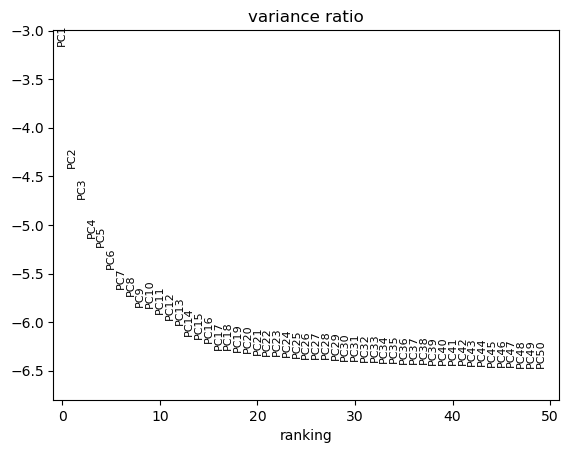

In [3]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

## 3. Build neighborhood graph


In [4]:
sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=30
)

C:\Users\dtquocbao\anaconda3\envs\spatial-breast-cancer\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


## 4. Run UMAP

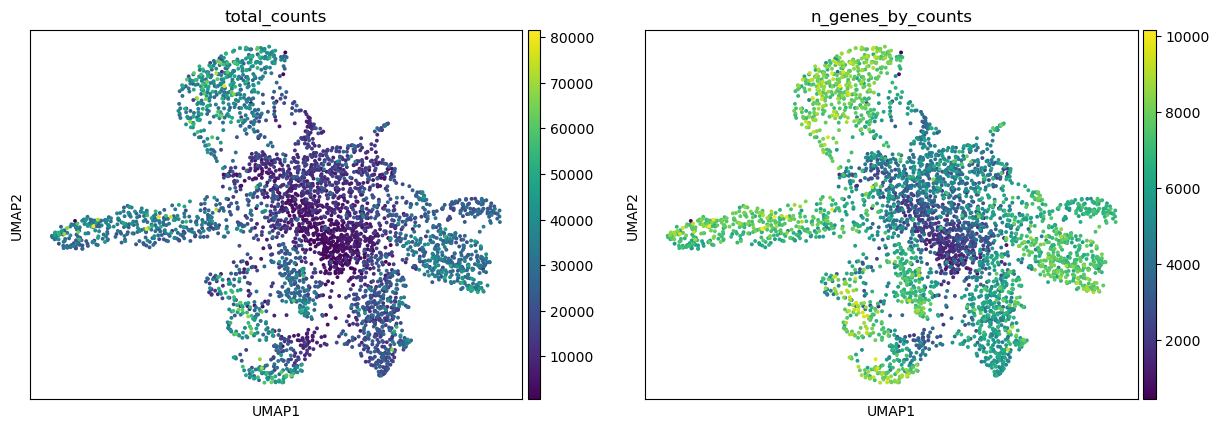

In [5]:
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["total_counts", "n_genes_by_counts"]
)

## 5. Run Leiden clustering

C:\Users\dtquocbao\AppData\Local\Temp\ipykernel_35848\3759608732.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


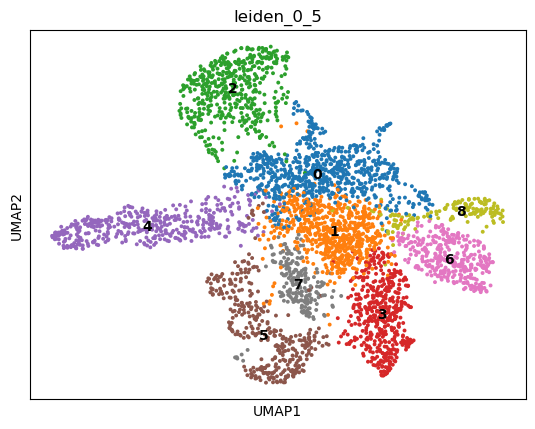

In [6]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added="leiden_0_5"
)

sc.pl.umap(
    adata,
    color="leiden_0_5",
    legend_loc="on data"
)

## Compare Leiden resolutions

Run clustering at several resolutions, then compare cluster granularity on UMAP.

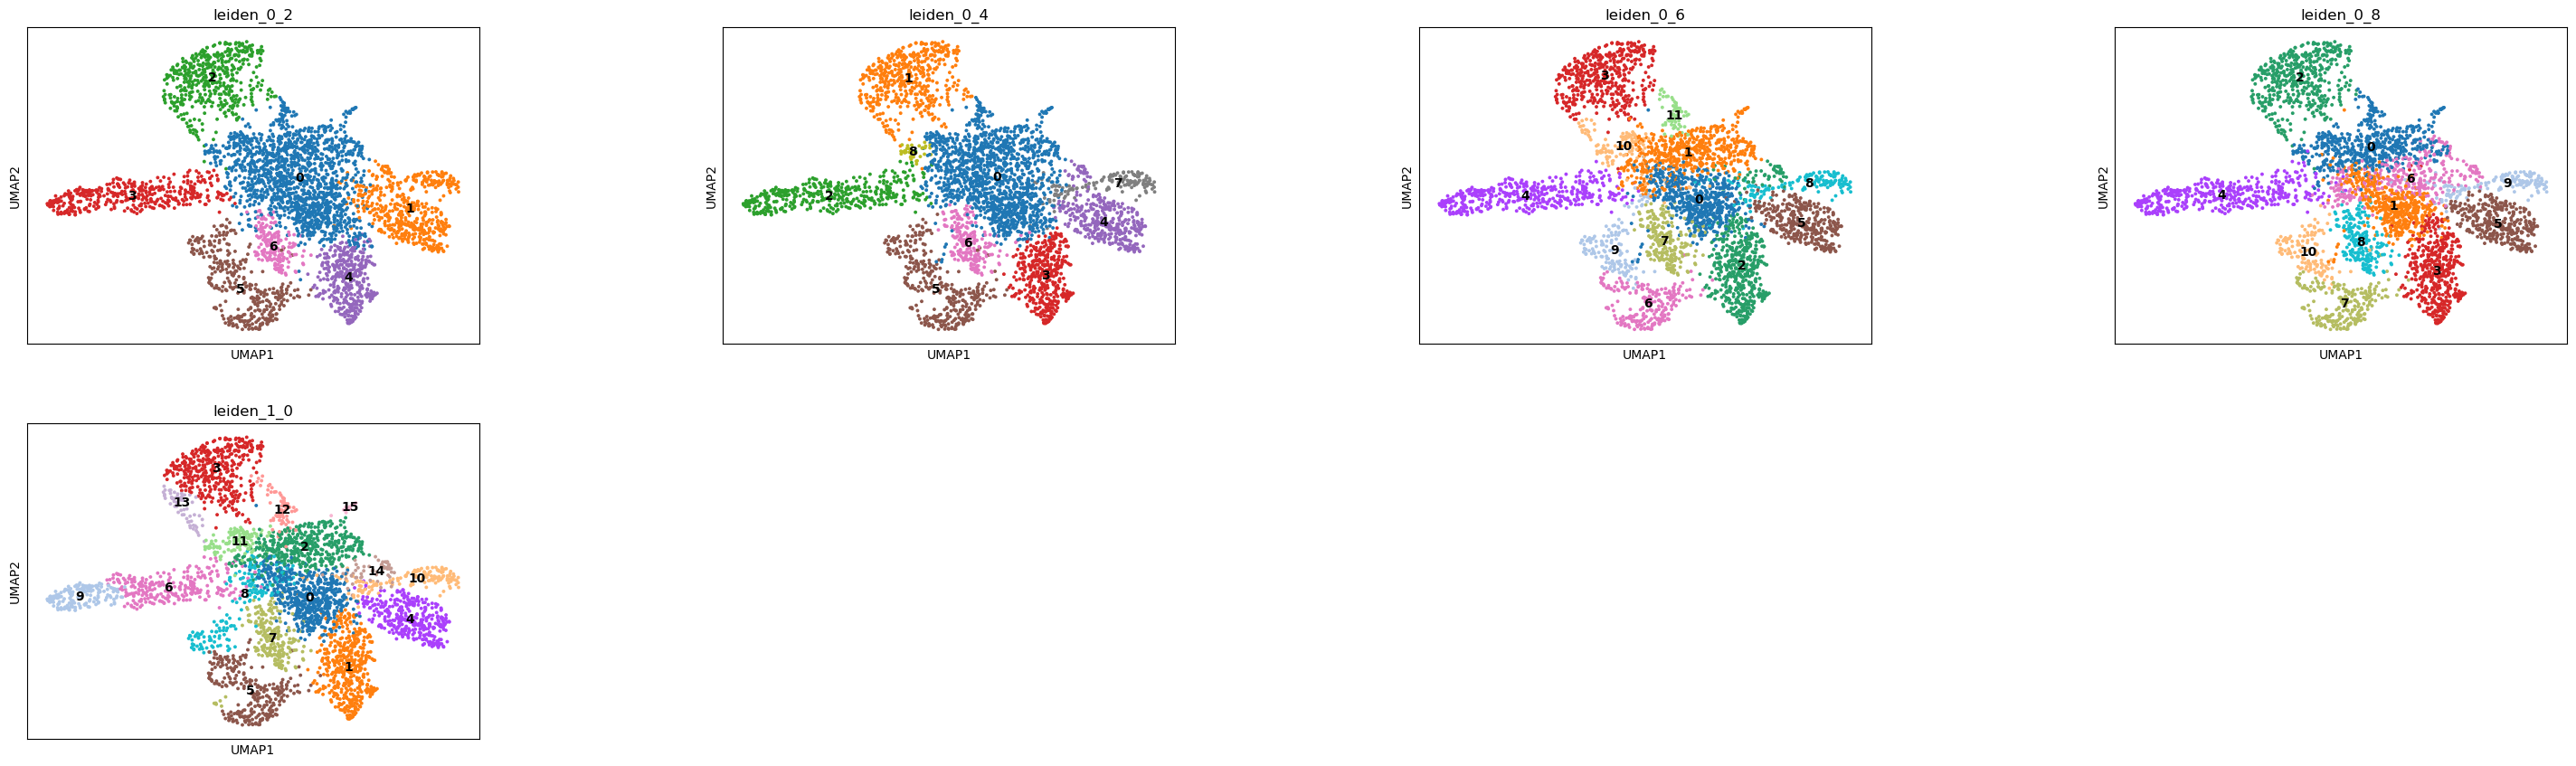

In [7]:
def leiden_key(resolution: float) -> str:
    return f"leiden_{resolution}".replace(".", "_")

compare_resolutions = [0.2, 0.4, 0.6, 0.8, 1.0]

for resolution in compare_resolutions:
    sc.tl.leiden(adata, resolution=resolution, key_added=leiden_key(resolution))

compare_keys = [leiden_key(r) for r in compare_resolutions]

sc.pl.umap(
    adata,
    color=compare_keys,
    legend_loc="on data",
    wspace=0.4,
)

## 6. Plot clusters on tissue image

C:\Users\dtquocbao\AppData\Local\Temp\ipykernel_35848\2821622460.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


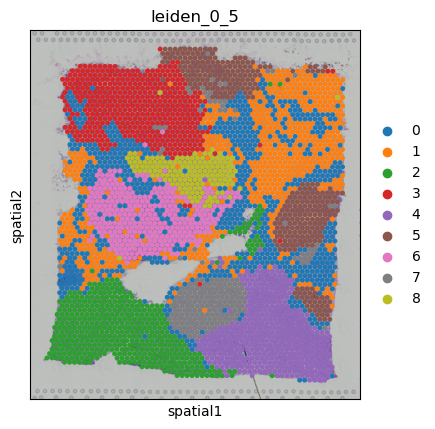

In [8]:
sc.pl.spatial(
    adata,
    color="leiden_0_5",
    img_key="hires",
    size=1.5
)

C:\Users\dtquocbao\AppData\Local\Temp\ipykernel_35848\1044313636.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


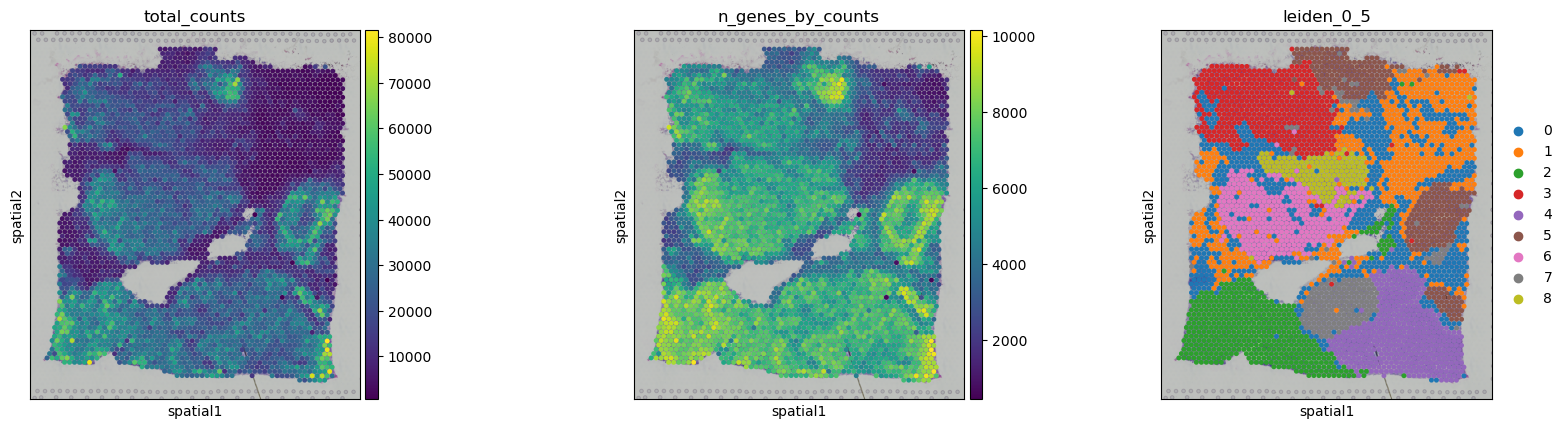

In [9]:
sc.pl.spatial(
    adata,
    color=["total_counts", "n_genes_by_counts", "leiden_0_5"],
    img_key="hires",
    size=1.5
)

## 7. Interpret clusters


## 8. Save result

In [ ]:
adata.write("../data/processed/breast_cancer_visium_clustered.h5ad")